# Práctica de Laboratorio 2: DS5345

Este cuaderno contiene la estructura necesaria para completar la práctica de laboratorio 2

**Nombre:** Jeffrey Monja Castro


In [ ]:
!pip install gymnasium numpy matplotlib

# PARTE I


## Configuración del Entorno


In [23]:
import gymnasium as gym
import numpy as np
import random
import time
import matplotlib.pyplot as plt

env = gym.make("Taxi-v4")
num_states = env.observation_space.n
num_actions = env.action_space.n

print(f"Estados: {num_states}, Acciones: {num_actions}")

Estados: 500, Acciones: 6


## Explorando el Entorno


In [ ]:
# Taxi-v4: estados, acciones y recompensas
action_names = ["Sur", "Norte", "Este", "Oeste", "Recoger", "Dejar pasajero"]
state, _ = env.reset(seed=42)
taxi_row, taxi_col, passenger_location, destination = env.unwrapped.decode(state)
possible_rewards = sorted(
    {
        transition[2]
        for actions in env.unwrapped.P.values()
        for transitions in actions.values()
        for transition in transitions
    }
)

print(f"Estados posibles: {env.observation_space.n}")
print("Un estado codifica: fila y columna del taxi, ubicacion del pasajero y destino.")
print(
    f"Ejemplo de estado {state}: taxi=({taxi_row}, {taxi_col}), pasajero={passenger_location}, destino={destination}"
)
print("Acciones:", dict(enumerate(action_names)))
print(f"Recompensas posibles: {possible_rewards}")

Estados posibles: 500
Un estado codifica: fila y columna del taxi, ubicacion del pasajero y destino.
Ejemplo de estado 386: taxi=(3, 4), pasajero=1, destino=2
Acciones: {0: 'Sur', 1: 'Norte', 2: 'Este', 3: 'Oeste', 4: 'Recoger', 5: 'Dejar pasajero'}
Recompensas posibles: [-10, -1, 20]


**Pregunta 1.1: Identifique cuántos estados posibles hay y qué representa cada acción.**

> Hay 500 estados posibles: 25 posiciones del taxi, 5 ubicaciones posibles del pasajero (R, G, Y, B o dentro del taxi) y 4 destinos. Las acciones son: 0=Sur, 1=Norte, 2=Este, 3=Oeste, 4=recoger y 5=dejar al pasajero.

**Pregunta 1.2: Revise el sistema de recompensas. ¿Qué penalización recibe el taxi por cada paso?**

> La penalización es **-1 por cada paso** que no produzca otra recompensa. Una recogida o entrega ilegal recibe -10, y dejar correctamente al pasajero entrega +20.


## 1. Política Epsilon-Greedy


In [4]:
def epsilon_greedy(Q, state, epsilon):
    if random.uniform(0, 1) < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])

## 2. Implementación de SARSA


In [20]:
Q_sarsa = np.zeros([num_states, num_actions])
sarsa_rewards = []

alpha = 0.1
gamma = 0.99
epsilon = 0.1

for episode in range(1000):
    state, _ = env.reset()
    action = epsilon_greedy(Q_sarsa, state, epsilon)
    done = False
    total_r = 0

    while not done:
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_action = epsilon_greedy(Q_sarsa, next_state, epsilon)

        # TODO: Implementar actualización SARSA
        # Q_sarsa[state, action] = ...
        td_target = reward + gamma * Q_sarsa[next_state, next_action]
        td_error = td_target - Q_sarsa[state, action]
        Q_sarsa[state, action] += alpha * td_error

        state, action = next_state, next_action
        total_r += reward

        done = terminated or truncated

    sarsa_rewards.append(total_r)

## 3. Implementación de Q-Learning


In [21]:
Q_ql = np.zeros([num_states, num_actions])
ql_rewards = []

for episode in range(1000):
    state, _ = env.reset()
    done = False
    total_r = 0

    while not done:
        action = epsilon_greedy(Q_ql, state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)

        # TODO: Implementar actualización Q-Learning
        # Q_ql[state, action] = ...
        td_target = reward + gamma * Q_ql[next_state].max()
        td_error = td_target - Q_ql[state, action]
        Q_ql[state, action] += alpha * td_error

        state = next_state
        total_r += reward

        done = terminated or truncated

    ql_rewards.append(total_r)

## 4. Bonus: Double Q-Learning


In [22]:
Q1 = np.zeros([num_states, num_actions])
Q2 = np.zeros([num_states, num_actions])
double_ql_rewards = []

for episode in range(1000):
    state, _ = env.reset()
    done = False
    total_r = 0

    while not done:
        action = epsilon_greedy(Q1 + Q2, state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)

        if random.uniform(0, 1) < 0.5:
            # Actualizar Q1
            td_target = reward + gamma * Q2[next_state, np.argmax(Q1[next_state])]
            td_error = td_target - Q1[state, action]
            Q1[state, action] += alpha * td_error
        else:
            # Actualizar Q2
            td_target = reward + gamma * Q1[next_state, np.argmax(Q2[next_state])]
            td_error = td_target - Q2[state, action]
            Q2[state, action] += alpha * td_error

        state = next_state
        total_r += reward

        done = terminated or truncated

    double_ql_rewards.append(total_r)

## Comparación de los algoritmos


In [ ]:
# Media movil para suavizar curva (ventana 20 episodios)
def moving_avg(data, window=20):
    return np.convolve(data, np.ones(window) / window, mode="valid")


def plot_comparison(rewards_sarsa, rewards_ql, rewards_double_ql):
    """Grafica comparativa SARSA vs Q-Learning."""
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(
        moving_avg(rewards_sarsa),
        color="#00AEEF",
        linewidth=2,
        label="SARSA (on-policy)",
    )
    ax.plot(
        moving_avg(rewards_ql),
        color="#EA580C",
        linewidth=2,
        label="Q-Learning (off-policy)",
    )
    ax.plot(
        moving_avg(rewards_double_ql),
        color="#FFB800",
        linewidth=2,
        label="Double Q-Learning",
    )
    ax.axhline(
        7.93,
        color="#00B383",
        linestyle="--",
        linewidth=1.2,
        label="Optimo teorico promedio (7.93)",
    )
    ax.set_xlabel("Episodio")
    ax.set_ylabel("Reward promedio (ventana 20)")
    ax.set_title("SARSA vs Q-Learning - Taxi-v4", fontweight="bold", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

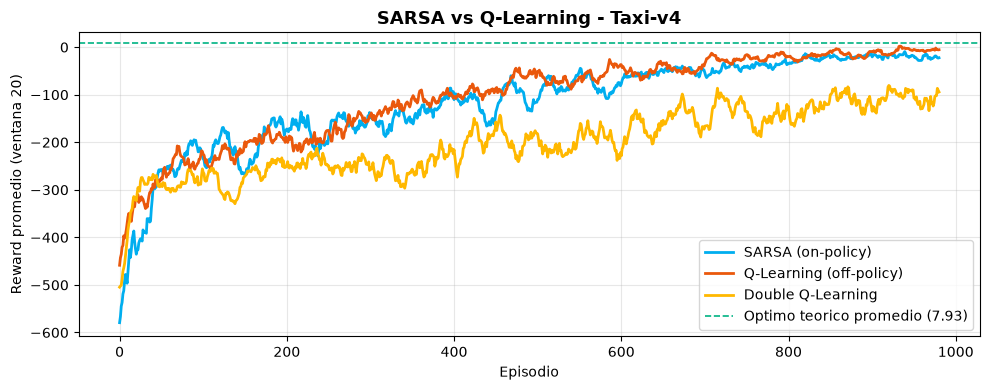

In [26]:
plot_comparison(sarsa_rewards, ql_rewards, double_ql_rewards)

**Análisis:**

> **Q-Learning** logra la mayor mejora: parte cerca de -450 y termina alrededor de -10, por lo que es el algoritmo que queda más cerca del óptimo teórico promedio (7.93). **SARSA** presenta una tendencia similar, pero al final se mantiene ligeramente por debajo de Q-Learning.
>
> **Double Q-Learning** mejora al inicio, pero conserva una recompensa más baja y oscilaciones grandes, cercanas a -100 al final. Con solo 1000 episodios y los mismos hiperparámetros, todavía no alcanza un desempeño comparable.
>
> Ninguna curva llega al óptimo teórico porque la política sigue explorando con $\epsilon=0.1$ y el entrenamiento es limitado; aun así, la tendencia ascendente de SARSA y Q-Learning muestra que aprendieron rutas progresivamente más eficientes.


# PARTE 2 VFA CON Q LEARNING


## 1. Exploracion del entorno


In [9]:
import gymnasium as gym
import numpy as np

env = gym.make("CartPole-v1")
state, _ = env.reset()

print("Estado inicial:", state)
print("Límites superiores:", env.observation_space.high)
print("Límites inferiores:", env.observation_space.low)

Estado inicial: [ 0.04145776  0.02152533 -0.03860423  0.00736311]
Límites superiores: [4.8               inf 0.41887903        inf]
Límites inferiores: [-4.8               -inf -0.41887903        -inf]


## Maldición de la dimensionalidad


**Pregunta 2.1: Si intentaras inicializar una tabla Q exacta para CartPole basándote en los límites del entorno, ¿qué problema de hardware y de probabilidad enfrentarías al intentar aprender una política óptima usando Q-Learning tabular tradicional?**

> CartPole tiene cuatro variables de estado continuas: posición y velocidad del carro, además de ángulo y velocidad angular del péndulo. Por ello, una tabla Q exacta requeriría una entrada para infinitos (no contables) estados y para cada una de las dos acciones: no cabe en memoria. Además, las velocidades tienen límites infinitos en el entorno, así que ni siquiera existe un rango finito completo que discretizar.
>
> Si se discretiza para hacerla finita, el número de celdas crece multiplicando las particiones de las cuatro dimensiones. Por ejemplo, 100 intervalos por variable producirían $100^4 \times 2 = 200$ millones de valores Q. El problema probabilístico es que la probabilidad de visitar exactamente el mismo estado continuo otra vez es prácticamente cero; por tanto, muchas celdas recibirían muy pocas experiencias y no se podrían estimar bien sus valores. Esta es la maldición de la dimensionalidad: memoria y datos necesarios crecen demasiado rápido. Por eso usamos aproximación de función: una actualización puede generalizarse a estados parecidos.


## 2. Aproximacion lineal con funcion valor


In [37]:
# 4 características del estado, 2 acciones posibles
weights = np.zeros((4, 2))


def predict_q(state, w):
    # Producto punto para obtener los valores Q de ambas acciones
    return np.dot(state, w)


# Predicción inicial (pesos en cero)
q_values = predict_q(state, weights)
print("Valores Q aproximados:", q_values)

Valores Q aproximados: [0. 0.]


**Pregunta 2.2: En nuestra aproximación lineal con la matriz de pesos, ¿qué sucede con la predicción de estados no visitados cuando actualizamos un peso w_i? ¿Por qué esto es una ventaja para espacios continuos?**

> Al ajustar un peso como $w_i$ estamos afectando la estimación de múltiples estados que comparten esa característica, lo que permite que el modelo aprenda de manera más eficiente y rápida en espacios continuos donde es imposible visitar todos los estados posibles.

> Es una ventaja en espacios continuos porque se en lugar de tener una tabla Q, se tiene una función $Q(s,a) = \theta^T \phi(s,a)$ que puede generalizar a estados no visitados, permitiendo que el agente aprenda políticas efectivas sin necesidad de explorar exhaustivamente cada estado posible.


## 3. Semigradiente con Q learning


In [31]:
def update_weights_qlearning(
    state, action, reward, next_state, w, alpha=0.01, gamma=0.99
):
    # 1. Predicción actual
    q_current = predict_q(state, w)[action]

    # 2. Predicción futura (Target) usando MAX para Q-Learning (Off-policy)
    q_next_max = np.max(predict_q(next_state, w))
    td_target = reward + gamma * q_next_max

    # 3. Error TD
    td_error = td_target - q_current

    # 4. Actualización (Semi-gradiente)
    # El gradiente de (state * w) respecto a w es simplemente 'state'
    w[:, action] += alpha * td_error * state

    return w

**Pregunta 2.3: Observa la fórmula y el código. El descenso de gradiente estándar requiere derivar la función de pérdida completa respecto a los pesos w. Sin embargo, en aprendizaje por refuerzo llamamos a esto “Semi-Gradiente”. ¿Por qué la derivación está incompleta (qué variable ignoramos al derivar) y por qué lo hacemos así de todos modos?**

> $y = r + \gamma \max_{a'} \hat Q_\theta(s',a')$ depende de $\theta$.
>
> **GD verdadero:** deriva $y$ y $\hat Q_\theta(s,a)$.
> **Semi-gradiente:** toma $y$ como constante:
> $\theta \leftarrow \theta + \alpha [y-\hat Q_\theta(s,a)]\phi(s,a)$.
>
> Ignoramos $\nabla_\theta y$ para una actualizacion TD simple y online.


## 4. Entrenamiento: Q-Learning lineal con features RBF

Normalizamos el estado y usamos RBF para aproximar $Q(s,a) = \theta^T \phi(s,a)$. Cada accion tiene su propio bloque de pesos.


In [ ]:
import matplotlib.pyplot as plt

# Escalas practicas: la posicion y el angulo se acotan al fallar;
# las velocidades se recortan para representarlas con RBF finitas.
state_scale = np.array([2.4, 3.0, np.deg2rad(12), 3.5])


def normalize_state(obs):
    return np.clip(np.asarray(obs, dtype=float) / state_scale, -1.0, 1.0)

In [33]:
# 3^4 = 81 centros RBF, mas un bias; dos bloques, uno por accion.
n_actions = env.action_space.n
rbf_grid = np.linspace(-1.0, 1.0, 3)
rbf_centers = np.stack(
    np.meshgrid(rbf_grid, rbf_grid, rbf_grid, rbf_grid, indexing="ij"), axis=-1
).reshape(-1, 4)
rbf_sigma = 0.75
features_per_action = len(rbf_centers) + 1
k_rbf = features_per_action * n_actions


def features_rbf(obs, action):
    normalized_obs = normalize_state(obs)
    squared_distance = np.sum((rbf_centers - normalized_obs) ** 2, axis=1)
    basis = np.r_[np.exp(-squared_distance / (2 * rbf_sigma**2)), 1.0]
    phi = np.zeros(k_rbf)
    start = action * features_per_action
    phi[start : start + features_per_action] = basis
    return phi


assert features_rbf(env.reset(seed=42)[0], 0).shape == (k_rbf,)
print(f"Centros RBF: {len(rbf_centers)} | Parametros totales: {k_rbf}")

Centros RBF: 81 | Parametros totales: 164


In [ ]:
def q_linear(
    env,
    feature_fn,
    k,
    n_episodes=1500,
    alpha=0.01,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.02,
    epsilon_decay=0.995,
    seed=42,
):
    """Q-Learning semi-gradiente con VFA lineal y RBF."""
    theta = np.zeros(k)
    rewards = []
    epsilon = epsilon_start
    rng = np.random.default_rng(seed)

    for episode in range(n_episodes):
        obs, _ = env.reset(seed=seed + episode)
        total_reward = 0
        done = False

        while not done:
            q_values = [
                np.dot(theta, feature_fn(obs, action)) for action in range(n_actions)
            ]
            action = (
                int(rng.integers(n_actions))
                if rng.random() < epsilon
                else int(np.argmax(q_values))
            )

            next_obs, reward, terminated, truncated, _ = env.step(action)
            phi = feature_fn(obs, action)
            next_q_max = max(
                np.dot(theta, feature_fn(next_obs, next_action))
                for next_action in range(n_actions)
            )
            target = reward if terminated else reward + gamma * next_q_max
            td_error = target - np.dot(theta, phi)
            theta += alpha * td_error * phi

            obs = next_obs
            total_reward += reward
            done = terminated or truncated

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_reward)

    return theta, rewards

Entrenando Q-Learning lineal con RBF...


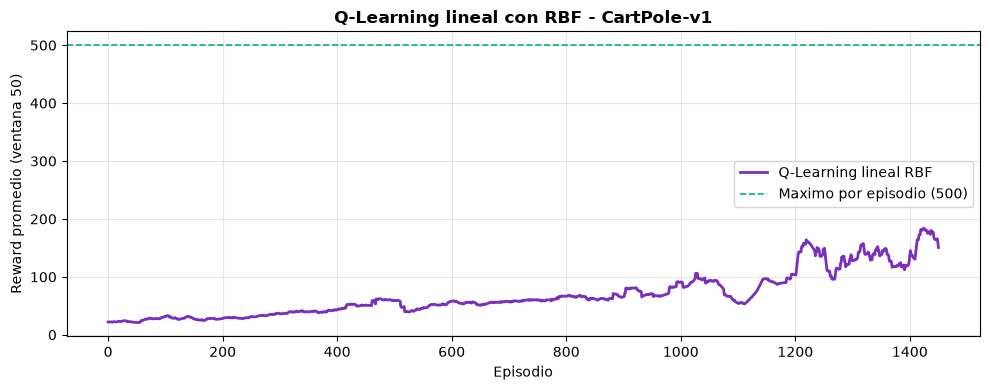

In [35]:
print("Entrenando Q-Learning lineal con RBF...")
theta_rbf, rewards_rbf = q_linear(env, features_rbf, k_rbf)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    moving_avg(rewards_rbf, 50),
    color="#7B2FBE",
    linewidth=2,
    label="Q-Learning lineal RBF",
)
ax.axhline(
    500,
    color="#00B383",
    linestyle="--",
    linewidth=1.2,
    label="Maximo por episodio (500)",
)
ax.set_xlabel("Episodio")
ax.set_ylabel("Reward promedio (ventana 50)")
ax.set_title("Q-Learning lineal con RBF - CartPole-v1", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
def evaluate_greedy(env, theta, feature_fn, n_episodes=20, seed=1000):
    rewards = []
    for episode in range(n_episodes):
        obs, _ = env.reset(seed=seed + episode)
        total_reward = 0
        done = False
        while not done:
            q_values = [
                np.dot(theta, feature_fn(obs, action)) for action in range(n_actions)
            ]
            action = int(np.argmax(q_values))
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        rewards.append(total_reward)
    return rewards


greedy_rewards = evaluate_greedy(env, theta_rbf, features_rbf)
print(f"Reward greedy medio (20 episodios): {np.mean(greedy_rewards):.1f}")
print(f"Minimo / maximo: {min(greedy_rewards):.0f} / {max(greedy_rewards):.0f}")

Reward greedy medio (20 episodios): 294.1
Minimo / maximo: 138 / 500


## 5. Bonus - Redes Neuronales


**Pregunta 2.4: Cuando usamos redes neuronales para Q-Learning, a menudo el entrenamiento diverge. A esto se le conoce como la Tríada Mortal (Deadly Triad). Investigando brevemente, ¿cuáles son los 3 elementos que componen esta tríada y por qué combinarlos dispara la inestabilidad?**

> Segun Sutton y Barto, la Triada Mortal combina:
>
> - **(1) aproximacion de funcion**, por ejemplo una VFA lineal o una red neuronal
> - **(2) bootstrapping**, porque el target TD usa una estimacion actual, como $r + \gamma \max_{a'} \hat Q(s',a')$
> - **(3) aprendizaje off-policy**, donde la politica de comportamiento que genera datos puede ser distinta de la politica objetivo.

> En nuestro Q-Learning con VFA aparecen los tres: las RBF comparten el vector $\theta$ entre muchos estados, el target usa $\max \hat Q$ y la conducta es $\epsilon$-greedy mientras el target es greedy. Un cambio en $\theta$ modifica simultaneamente muchas predicciones y tambien los targets futuros; si estos targets se calculan sobre acciones distintas de las que generaron los datos, el error puede realimentarse, producir oscilaciones o crecer sin limite. Sutton y Barto enfatizan que el peligro ya existe aun en prediccion; no depende de que el entorno sea desconocido ni de usar control. Si se elimina cualquiera de los tres elementos, la inestabilidad puede evitarse.
